<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/notebooks/kan_vs_mlp_sp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Часть 1. Генерация данных**

Установка библиотек

In [1]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-d0piamc_
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-d0piamc_
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=3d25f59ab321d7c5430faf8ffc98fae19add14b6085628c6b66e110fb4bbfbf3
  Stored in directory: /tmp/pip-ephem-wheel-cache-aj37vmam/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


1.1. Генерация траекторий численным интегрированием: координата *x(t)*, скорость *v(t)* и ускорение *a(t)* при **разных начальных условиях** и **разных константах** *k*, *c* - жесткости пружины и сопротивления среды.

In [2]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []
m = 1.0  # масса маятника

for k in [2.0]: # цикл по жесткости и сопротивлению [2.0, 4.0, 6.0]
    for c in [0.1]: # [0.1, 0.5, 1.0]

        for x0 in [1.0, 0.5, 2.0]: # цикл по начальным условиям
            for v0 in [0.0, 0.5, -0.5]:

                sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 500))
                # запуск численного интегрирования от t[0,20], 500 значений

                x, v = sol.y # извлечение из результата (sol) массив из координат и скоростей
                a = -(k/m)*x - (c/m)*v # вычисление ускорения

                # сохрание точек (x, v, a)
                for i in range(len(x)):
                    all_data.append([x[i], v[i], a[i]])

all_data = np.array(all_data)
print(len(all_data))

4500


1.2. Формирование датасета из полученных данных

In [3]:
X = all_data[:, :2]   # (x, v)
y = all_data[:, 2]    # a

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование (рекомендуется для MLP, для KAN здесь тоже не помешает)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

# Преобразование в тензоры
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1,1)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled, dtype=torch.float32).reshape(-1,1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

train: 3600 примеров, test: 900 примеров


# **Часть 2. Создание и обучение KAN [2,2,1] (66 параметров)**

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.28e-03 | test_loss: 5.52e-03 | reg: 9.21e+00 | : 100%|█| 30/30 [00:05<00:00,  5.62it


saving model version 0.1


| train_loss: 3.37e-03 | test_loss: 3.40e-03 | reg: 9.35e+00 | : 100%|█| 30/30 [00:05<00:00,  5.60it


saving model version 0.2


...

saving model version 0.9


| train_loss: 6.14e-05 | test_loss: 7.11e-05 | reg: 9.34e+00 | : 100%|█| 30/30 [00:01<00:00, 23.97it


saving model version 0.10


| train_loss: 6.14e-05 | test_loss: 7.12e-05 | reg: 9.34e+00 | : 100%|█| 300/300 [00:13<00:00, 23.03


saving model version 0.11


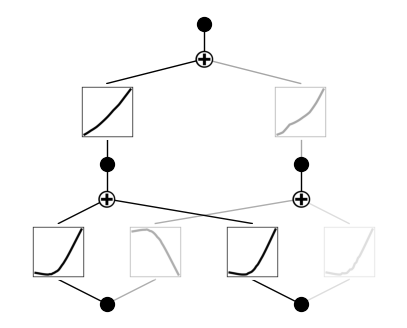

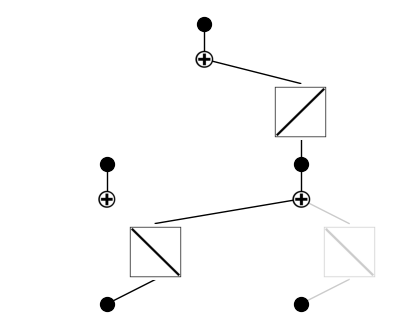

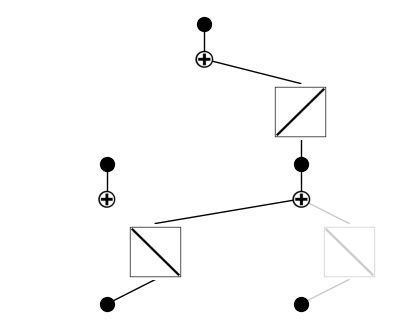

In [11]:
model_kan = KAN(width=[2, 2, 1], grid=10, k=1, seed=42, device=device)

model_kan(dataset['train_input']) # инициализация, визуализация
model_kan.plot()

steps = 10
train_losses_kan = []
test_losses_kan = []

# обучаем по одному шагу, сохраняя ошибки
for step in range(steps):
    result = model_kan.fit(dataset, opt="LBFGS", steps=30, lamb=0.0, lamb_entropy=0.0)

    train_losses_kan.append(result['train_loss'])
    test_losses_kan.append(result['test_loss'])

model_kan.plot()

# # ошибка на тесте (масштабированные единицы)
# with torch.no_grad():
#     pred_kan_scaled = model_kan(dataset['test_input'])
#     mse_kan_scaled = nn.functional.mse_loss(pred_kan_scaled, dataset['test_label'])
# print(f"MSE KAN (scaled): {mse_kan_scaled.item():.8f}")

In [12]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)

ex_round(model_kan.symbolic_formula()[0][0],4)

fixing (0,0,0) with x, r2=0.7069093585014343, c=1
fixing (0,0,1) with x, r2=0.9999997019767761, c=1
fixing (0,1,0) with x, r2=0.8133956789970398, c=1
fixing (0,1,1) with x, r2=0.9999991059303284, c=1
fixing (1,0,0) with x, r2=0.3393169939517975, c=1
fixing (1,1,0) with x, r2=0.9999997615814209, c=1
saving model version 0.12


-1.0017*x_1 - 0.0704*x_2

# **Часть 3. Создание и обучение MLP [2,16,1] (65 параметров)**

In [14]:
class MLP(nn.Module):
    def __init__(self): # конструктор
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x): # описывает как данные проходят через сеть
        return self.net(x)

model_mlp = MLP()
criterion = nn.MSELoss() # функция потерь
optimizer = optim.Adam(model_mlp.parameters(), lr=0.01) # оптимизатор

# обучение
epochs = 5000
train_losses_mlp = []
test_losses_mlp = []

for epoch in range(epochs):
    model_mlp.train() # перевод в режим обучения
    optimizer.zero_grad() # обнуление градиентов
    # прямой проход
    pred = model_mlp(dataset['train_input'])
    loss = criterion(pred, dataset['train_label'])
    # обратный проход
    loss.backward()
    optimizer.step()

    model_mlp.eval() # перевод в режим оценки
    with torch.no_grad(): # отключение вычисления градиентов для тестов
        test_loss = criterion(model_mlp(dataset['test_input']), dataset['test_label'])

    # сохранение значений среднеквадратичной ошибки
    train_losses_mlp.append(loss.item())
    test_losses_mlp.append(test_loss.item())

    # Вывод каждые 500 эпох
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs} | train_loss: {loss.item():.6f} | test_loss: {test_loss.item():.6f}")

Epoch 500/5000 | train_loss: 0.000035 | test_loss: 0.000036
Epoch 1000/5000 | train_loss: 0.000001 | test_loss: 0.000001
Epoch 1500/5000 | train_loss: 0.000000 | test_loss: 0.000000
Epoch 2000/5000 | train_loss: 0.000000 | test_loss: 0.000000
Epoch 2500/5000 | train_loss: 0.000000 | test_loss: 0.000000
Epoch 3000/5000 | train_loss: 0.000000 | test_loss: 0.000000
Epoch 3500/5000 | train_loss: 0.000000 | test_loss: 0.000000
Epoch 4000/5000 | train_loss: 0.000000 | test_loss: 0.000000
Epoch 4500/5000 | train_loss: 0.000001 | test_loss: 0.000001
Epoch 5000/5000 | train_loss: 0.000000 | test_loss: 0.000000


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(train_losses_kan, label='KAN Train', color='blue', linestyle='-')
plt.plot(test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')

plt.plot(train_losses_mlp, label='MLP Train', color='orange', linestyle='-')
plt.plot(test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')

plt.xlabel('Step / Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.title('Сравнение обучения KAN и MLP')
plt.show()